TASK 2: Unemployment Analysis with Python

● Analyze unemployment rate data representing unemployed people percentage.

● Use Python for data cleaning, exploration, and visualization of unemployment trends.

● Investigate the impact of Covid-19 on unemployment rates.

● Identify key patterns or seasonal trends in the data.

● Present insights that could inform economic or social policies.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

2. Import the Dataset

In [ ]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

df.head()

Dataset loaded successfully!
Shape of dataset: (768, 7)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


3. Data Cleaning

In [ ]:
# Remove unnecessary spaces from column names
df.columns = df.columns.str.strip()

# Display column names
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


In [ ]:
# Remove rows containing missing values
df = df.dropna().copy()

print("Shape after removing missing values:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Shape after removing missing values: (740, 7)

Missing values after cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


4. Convert Date Column

In [ ]:
# Convert Date column into datetime format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort data according to date
df = df.sort_values('Date')

print(df['Date'].head())

0     2019-05-31
290   2019-05-31
276   2019-05-31
257   2019-05-31
243   2019-05-31
Name: Date, dtype: datetime64[ns]


5. Basic Information About Dataset

In [ ]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [ ]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


6. Unemployment Rate Analysis

In [ ]:
average_unemployment = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:",
      round(average_unemployment, 2), "%")

Average Unemployment Rate: 11.79 %


7. Overall Unemployment Trend

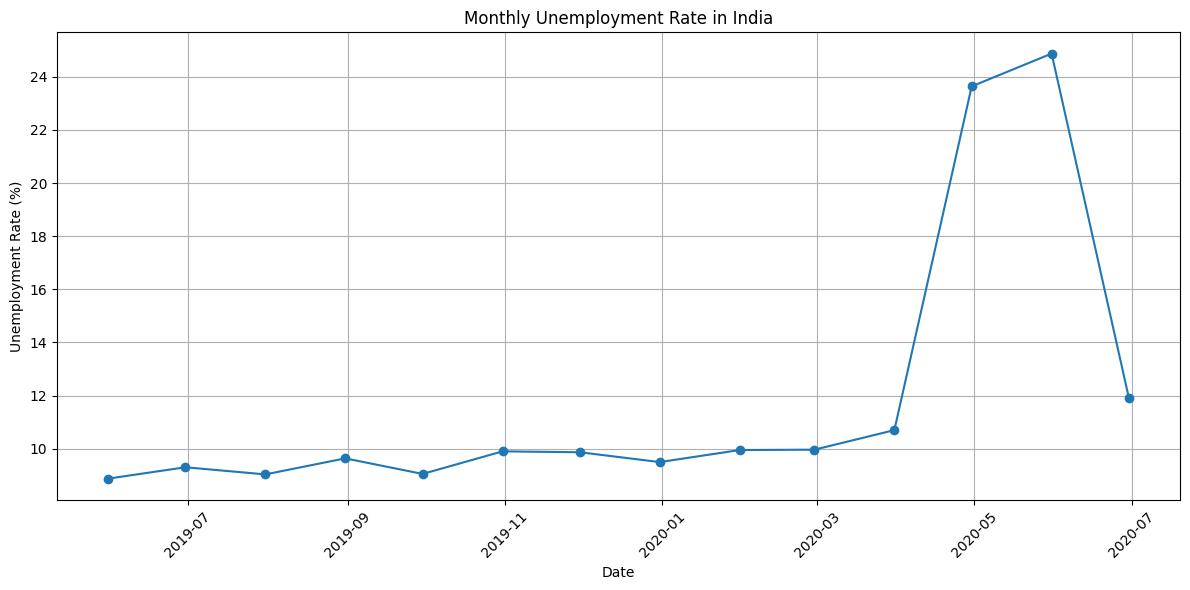

In [ ]:
monthly_unemployment = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_unemployment['Date'],
    monthly_unemployment['Estimated Unemployment Rate (%)'],
    marker='o'
)

plt.title('Monthly Unemployment Rate in India')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation

The graph shows that unemployment was relatively moderate during the pre-COVID period but increased sharply during the COVID-19 period.

8. Region-wise Unemployment Analysis

In [ ]:
region_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
      .mean()
      .sort_values(ascending=False)
)

print(region_unemployment)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


Visualization

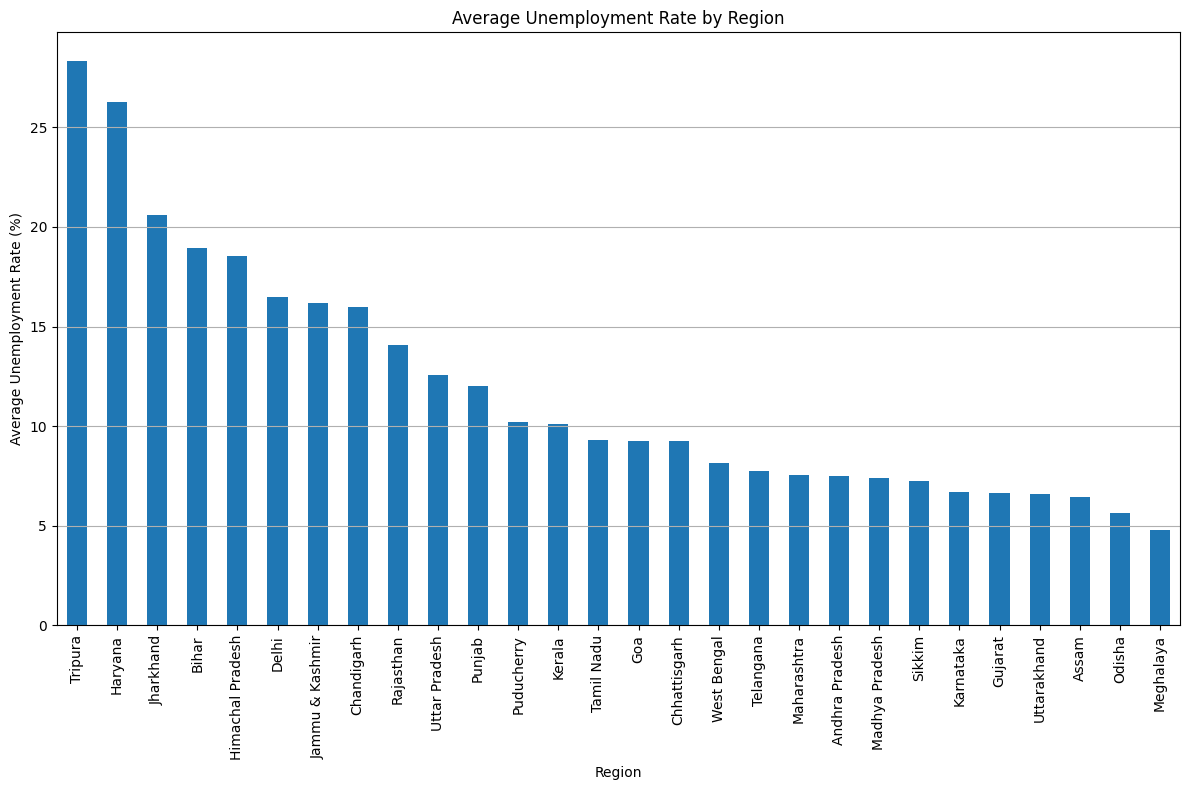

In [ ]:
plt.figure(figsize=(12,8))

region_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate by Region')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Interpretation

This graph helps identify regions with comparatively high and low unemployment rates.

9. Rural vs Urban Unemployment

In [ ]:
area_unemployment = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
      .mean()
)

print(area_unemployment)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


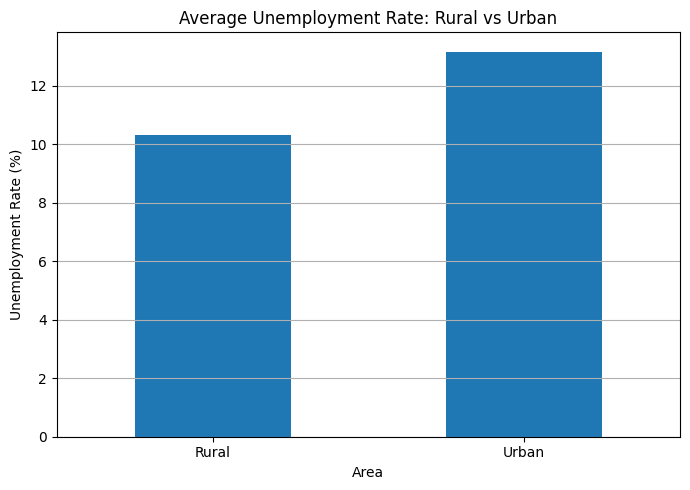

In [ ]:
plt.figure(figsize=(7,5))

area_unemployment.plot(kind='bar')

plt.title('Average Unemployment Rate: Rural vs Urban')
plt.xlabel('Area')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Interpretation-

Therefore, urban unemployment was higher on average, and both rural and urban areas experienced a substantial increase during COVID-19.

10. COVID-19 Impact on Unemployment
We will divide the dataset into:

Pre-COVID: before March 2020

COVID-19: March 2020 onwards

In [ ]:
df['Period'] = np.where(
    df['Date'] < '2020-03-01',
    'Pre-COVID',
    'COVID-19'
)

df[['Date', 'Period']].head()


,Date,Period
0,2019-05-31,Pre-COVID
290,2019-05-31,Pre-COVID
276,2019-05-31,Pre-COVID
257,2019-05-31,Pre-COVID
243,2019-05-31,Pre-COVID


11. Compare Pre-COVID and COVID Unemployment

In [ ]:
covid_comparison = (
    df.groupby('Period')['Estimated Unemployment Rate (%)']
      .agg(['mean', 'median', 'min', 'max'])
)

print(covid_comparison.round(2))

            mean  median  min    max
Period                              
COVID-19   17.77   14.52  0.0  76.74
Pre-COVID   9.51    7.12  0.0  34.69


12. COVID-19 Impact Visualization

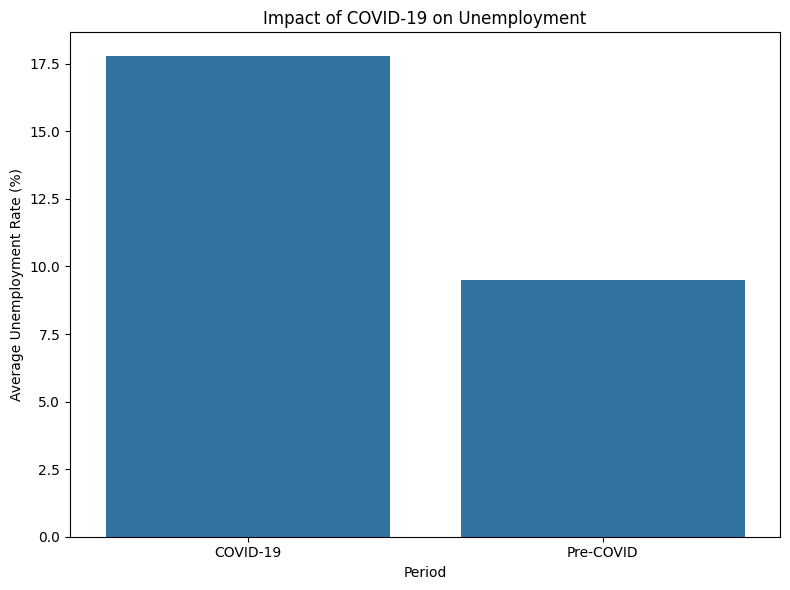

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison['mean']
)

plt.title('Impact of COVID-19 on Unemployment')
plt.xlabel('Period')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

Interpretation

The visualization clearly indicates a major increase in unemployment during the COVID-19 period.

13. Monthly COVID-19 Trend

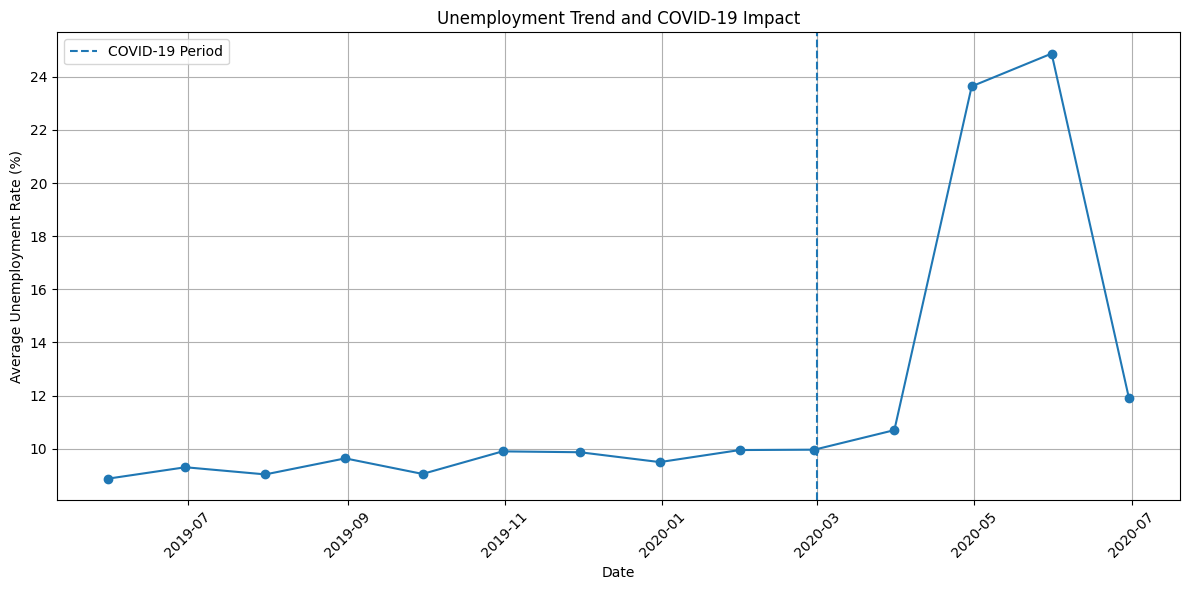

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly_covid = (
    df.groupby('Date')['Estimated Unemployment Rate (%)']
      .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_covid.index,
    monthly_covid.values,
    marker='o'
)

plt.axvline(
    pd.Timestamp('2020-03-01'),
    linestyle='--',
    label='COVID-19 Period'
)

plt.title('Unemployment Trend and COVID-19 Impact')
plt.xlabel('Date')
plt.ylabel('Average Unemployment Rate (%)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Important observation

The unemployment rate reaches its highest monthly average around May 2020, approximately 24.88% in this dataset.

This indicates a very strong short-term labour-market shock during the early COVID-19 period.

14. Identify Highest and Lowest Unemployment Months

In [ ]:
max_date = monthly_covid.idxmax()
max_rate = monthly_covid.max()

min_date = monthly_covid.idxmin()
min_rate = monthly_covid.min()

print("Highest unemployment:")
print("Date:", max_date.strftime('%B %Y'))
print("Rate:", round(max_rate, 2), "%")

print("\nLowest unemployment:")
print("Date:", min_date.strftime('%B %Y'))
print("Rate:", round(min_rate, 2), "%")

Highest unemployment:
Date: May 2020
Rate: 24.88 %

Lowest unemployment:
Date: May 2019
Rate: 8.87 %


15. Seasonal Trend Analysis

In [ ]:
df['Month_Name'] = df['Date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_average = (
    df.groupby('Month_Name')['Estimated Unemployment Rate (%)']
      .mean()
      .reindex(month_order)
)

print(monthly_average.round(2))

Month_Name
January       9.95
February      9.96
March        10.70
April        23.64
May          16.65
June         10.55
July          9.03
August        9.64
September     9.05
October       9.90
November      9.87
December      9.50
Name: Estimated Unemployment Rate (%), dtype: float64


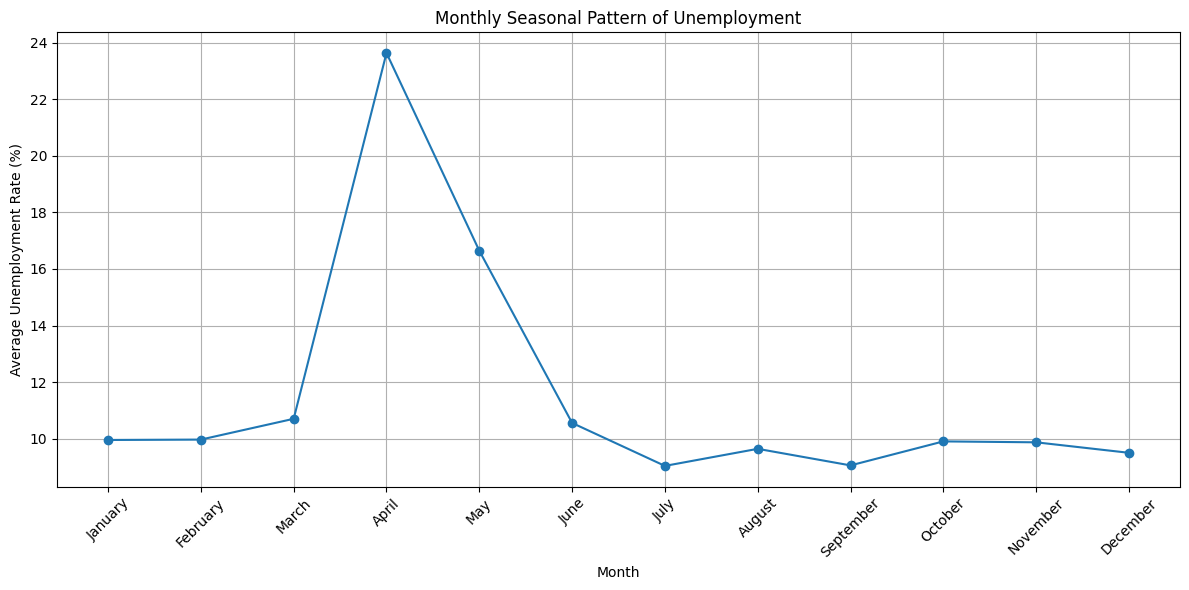

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_average.index,
    monthly_average.values,
    marker='o'
)

plt.title('Monthly Seasonal Pattern of Unemployment')
plt.xlabel('Month')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation

The monthly pattern shows variation across the year. However, the extremely high values around April–May 2020 are strongly associated with the COVID-19 shock rather than ordinary seasonal variation.

16. State/Region-wise COVID Impact

In [ ]:
region_covid = (
    df.groupby(['Region', 'Period'])
      ['Estimated Unemployment Rate (%)']
      .mean()
      .unstack()
)

region_covid['Increase'] = (
    region_covid['COVID-19'] -
    region_covid['Pre-COVID']
)

region_covid = region_covid.sort_values(
    'Increase',
    ascending=False
)

print(region_covid.round(2))

Period            COVID-19  Pre-COVID  Increase
Region                                         
Puducherry           38.96       1.59     37.36
Tamil Nadu           25.40       2.84     22.57
Jharkhand            36.35      14.28     22.07
Bihar                31.63      13.83     17.80
Karnataka            15.28       3.23     12.05
Haryana              34.65      22.94     11.72
Kerala               17.95       6.99     10.96
Telangana            15.44       4.66     10.79
Madhya Pradesh       14.07       4.74      9.33
Andhra Pradesh       13.58       5.04      8.54
Delhi                22.16      14.23      7.93
Odisha               11.28       3.41      7.87
Maharashtra          13.03       5.37      7.66
Uttar Pradesh        17.38      10.62      6.76
West Bengal          12.01       6.57      5.44
Chhattisgarh         13.08       7.71      5.37
Gujarat              10.38       5.18      5.21
Goa                  13.11       8.51      4.60
Rajasthan            17.31      12.76   

Top regions affected

In [ ]:
print("Top 10 regions with largest increase in unemployment:")

print(
    region_covid[['Pre-COVID', 'COVID-19', 'Increase']]
    .head(10)
    .round(2)
)

Top 10 regions with largest increase in unemployment:
Period          Pre-COVID  COVID-19  Increase
Region                                       
Puducherry           1.59     38.96     37.36
Tamil Nadu           2.84     25.40     22.57
Jharkhand           14.28     36.35     22.07
Bihar               13.83     31.63     17.80
Karnataka            3.23     15.28     12.05
Haryana             22.94     34.65     11.72
Kerala               6.99     17.95     10.96
Telangana            4.66     15.44     10.79
Madhya Pradesh       4.74     14.07      9.33
Andhra Pradesh       5.04     13.58      8.54


17. Employment and Labour Participation Analysis


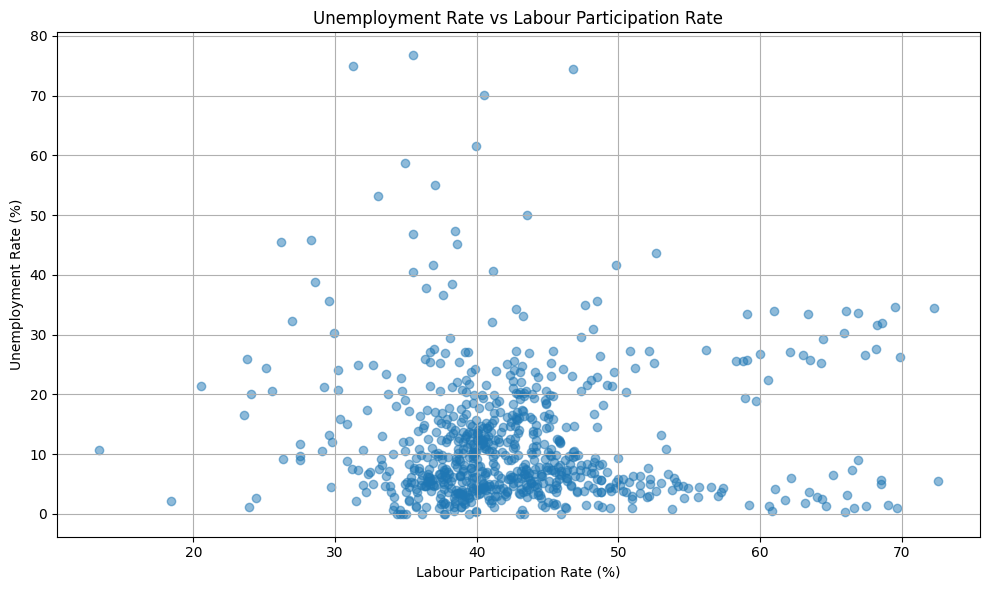

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Estimated Labour Participation Rate (%)'],
    df['Estimated Unemployment Rate (%)'],
    alpha=0.5
)

plt.title('Unemployment Rate vs Labour Participation Rate')
plt.xlabel('Labour Participation Rate (%)')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

Interpretation

This plot helps investigate the relationship between labour-force participation and unemployment. The relationship is not necessarily linear and varies considerably across regions and time periods.

18. Correlation Analysis

In [ ]:
correlation = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

print(correlation.round(3))

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                    1.000   
Estimated Employed                                                -0.223   
Estimated Labour Participation Rate (%)                            0.003   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                      -0.223   
Estimated Employed                                    1.000   
Estimated Labour Participation Rate (%)               0.011   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                            0.003  
Estimated Employed                                                         0.011  
Estimated Labour Participation Rate (%)                                    1.000  


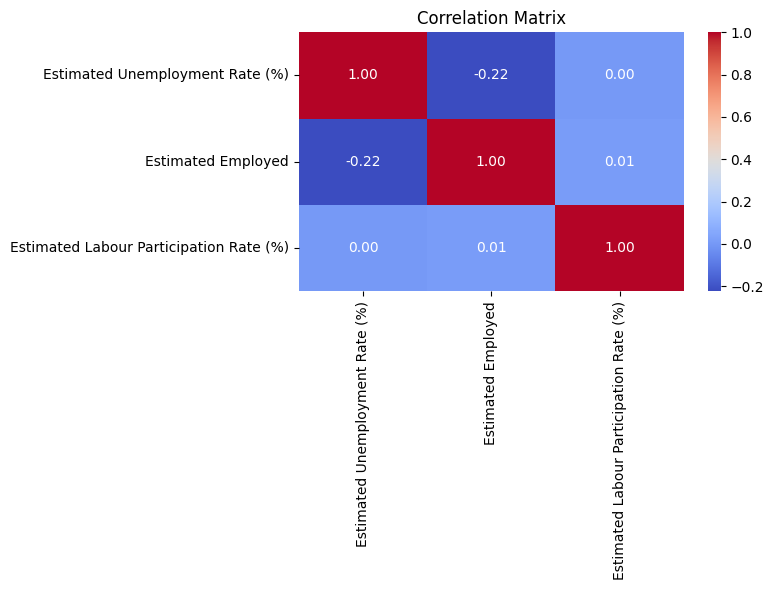

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

19. Top 10 Highest Unemployment Observations

In [ ]:
top10 = df.sort_values(
    'Estimated Unemployment Rate (%)',
    ascending=False
).head(10)

print(
    top10[
        [
            'Region',
            'Date',
            'Estimated Unemployment Rate (%)',
            'Area'
        ]
    ].to_string(index=False)
)

          Region       Date  Estimated Unemployment Rate (%)  Area
      Puducherry 2020-04-30                            76.74 Urban
      Puducherry 2020-05-31                            75.00 Urban
      Puducherry 2020-04-30                            74.51 Rural
       Jharkhand 2020-05-31                            70.17 Urban
       Jharkhand 2020-04-30                            61.48 Urban
           Bihar 2020-04-30                            58.77 Urban
       Jharkhand 2020-05-31                            55.10 Rural
      Tamil Nadu 2020-04-30                            53.19 Rural
Himachal Pradesh 2020-05-31                            50.00 Urban
           Bihar 2020-05-31                            47.26 Rural


20. Complete Analysis in One Summary Table

In [ ]:
summary = pd.DataFrame({
    'Measure': [
        'Total observations after cleaning',
        'Average unemployment rate',
        'Pre-COVID average unemployment',
        'COVID-19 average unemployment',
        'Increase during COVID',
        'Highest monthly average',
        'Lowest monthly average'
    ],
    'Value': [
        len(df),
        round(df['Estimated Unemployment Rate (%)'].mean(), 2),
        round(
            df.loc[df['Period'] == 'Pre-COVID',
                   'Estimated Unemployment Rate (%)'].mean(), 2
        ),
        round(
            df.loc[df['Period'] == 'COVID-19',
                   'Estimated Unemployment Rate (%)'].mean(), 2
        ),
        round(
            df.loc[df['Period'] == 'COVID-19',
                   'Estimated Unemployment Rate (%)'].mean()
            -
            df.loc[df['Period'] == 'Pre-COVID',
                   'Estimated Unemployment Rate (%)'].mean(),
            2
        ),
        round(monthly_covid.max(), 2),
        round(monthly_covid.min(), 2)
    ]
})

print(summary.to_string(index=False))

                          Measure  Value
Total observations after cleaning 740.00
        Average unemployment rate  11.79
   Pre-COVID average unemployment   9.51
    COVID-19 average unemployment  17.77
            Increase during COVID   8.26
          Highest monthly average  24.88
           Lowest monthly average   8.87


21. Final Conclusion:

The analysis of unemployment data in India shows significant variation in unemployment rates across different regions, areas, and time periods. The data indicates that unemployment increased substantially during the COVID-19 period, with the average unemployment rate rising from approximately 9.51% before COVID-19 to 17.77% during the COVID-19 period. The highest monthly average unemployment rate was observed around May 2020, at approximately 24.88%.

Urban areas generally experienced higher unemployment than rural areas. The analysis also reveals differences among regions, with some regions experiencing much larger increases in unemployment during the pandemic.

Overall, the results suggest that COVID-19 had a severe negative impact on employment in India. These findings can help policymakers design measures such as employment-generation programmes, skill-development initiatives, support for small businesses, and targeted assistance to highly affected regions. Seasonal analysis should be interpreted carefully because the unusually large unemployment increase in early 2020 was strongly influenced by the pandemic.